In [ ]:
import pandas as pd
import h5py
import numpy as np
import matplotlib.pyplot as plt
import random

# Path ke file hasil "Grand Merger" Anda
HDF5_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/2010/STEAD_Indonesia_2010.hdf5'
CSV_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/2010/STEAD_Indonesia_2010_Metadata.csv'

# 1. Baca Buku Indeks (Metadata)
df = pd.read_csv(CSV_PATH)

# Pisahkan daftar nama trace berdasarkan kategorinya
gempa_list = df[df['trace_category'] == 'earthquake_local']['trace_name'].tolist()
noise_list = df[df['trace_category'] == 'noise']['trace_name'].tolist()

# Pilih 1 gempa dan 1 noise secara acak
trace_gempa = random.choice(gempa_list) if gempa_list else None
trace_noise = random.choice(noise_list) if noise_list else None

# Fungsi untuk mem-plot 3 komponen ala STEAD
def plot_waveform(data_array, title):
    # Sumbu X (Waktu) -> 6000 sampel dibagi 100 Hz = 60 detik
    t = np.linspace(0, 60, 6000)
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    komponen = ['Timur (E)', 'Utara (N)', 'Vertikal (Z)']
    warna = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for i in range(3):
        axes[i].plot(t, data_array[:, i], color=warna[i], linewidth=0.8)
        axes[i].set_ylabel(komponen[i], fontsize=10)
        axes[i].grid(True, linestyle='--', alpha=0.6)
        
    axes[2].set_xlabel("Waktu (Detik)", fontsize=12)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

# 2. Buka Brankas HDF5 dan Plot Datanya
with h5py.File(HDF5_PATH, 'r') as hf:
    
    if trace_gempa and trace_gempa in hf:
        print(f"Menggambar Gelombang Gempa: {trace_gempa}")
        data_gempa = hf[trace_gempa][:]
        plot_waveform(data_gempa, f"Kategori: Gempa Bumi Lokal (LE)\nTrace: {trace_gempa}")
        
    if trace_noise and trace_noise in hf:
        print(f"Menggambar Gelombang Bising: {trace_noise}")
        data_noise = hf[trace_noise][:]
        plot_waveform(data_noise, f"Kategori: Seismik Noise (NO)\nTrace: {trace_noise}")

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import random

HDF5_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/STEAD_Indonesia_2004_2010_Final.hdf5'

def plot_random_samples(hdf5_path):
    with h5py.File(hdf5_path, 'r') as hf:
        # Pisahkan keys berdasarkan kategori
        le_keys = [k for k in hf.keys() if hf[k].attrs['category'] == 'earthquake_local']
        no_keys = [k for k in hf.keys() if hf[k].attrs['category'] == 'noise']
        
        # Ambil sampel acak
        le_sample = random.choice(le_keys)
        no_sample = random.choice(no_keys)
        
        data_le = hf[le_sample][:] # Matriks (6000, 3)
        data_no = hf[no_sample][:]
        
        # Plotting
        fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
        components = ['Timur (E)', 'Utara (N)', 'Vertikal (Z)']
        
        # Plot Gempa
        for i in range(3):
            axes[0, i].plot(data_le[:, i], color='red', linewidth=0.5)
            axes[0, i].set_title(f"LE: {le_sample} | {components[i]}")
            axes[0, i].grid(True, alpha=0.3)
            
        # Plot Noise
        for i in range(3):
            axes[1, i].plot(data_no[:, i], color='blue', linewidth=0.5)
            axes[1, i].set_title(f"NO: {no_sample} | {components[i]}")
            axes[1, i].grid(True, alpha=0.3)
            
        plt.tight_layout()
        plt.show()

plot_random_samples(HDF5_PATH)

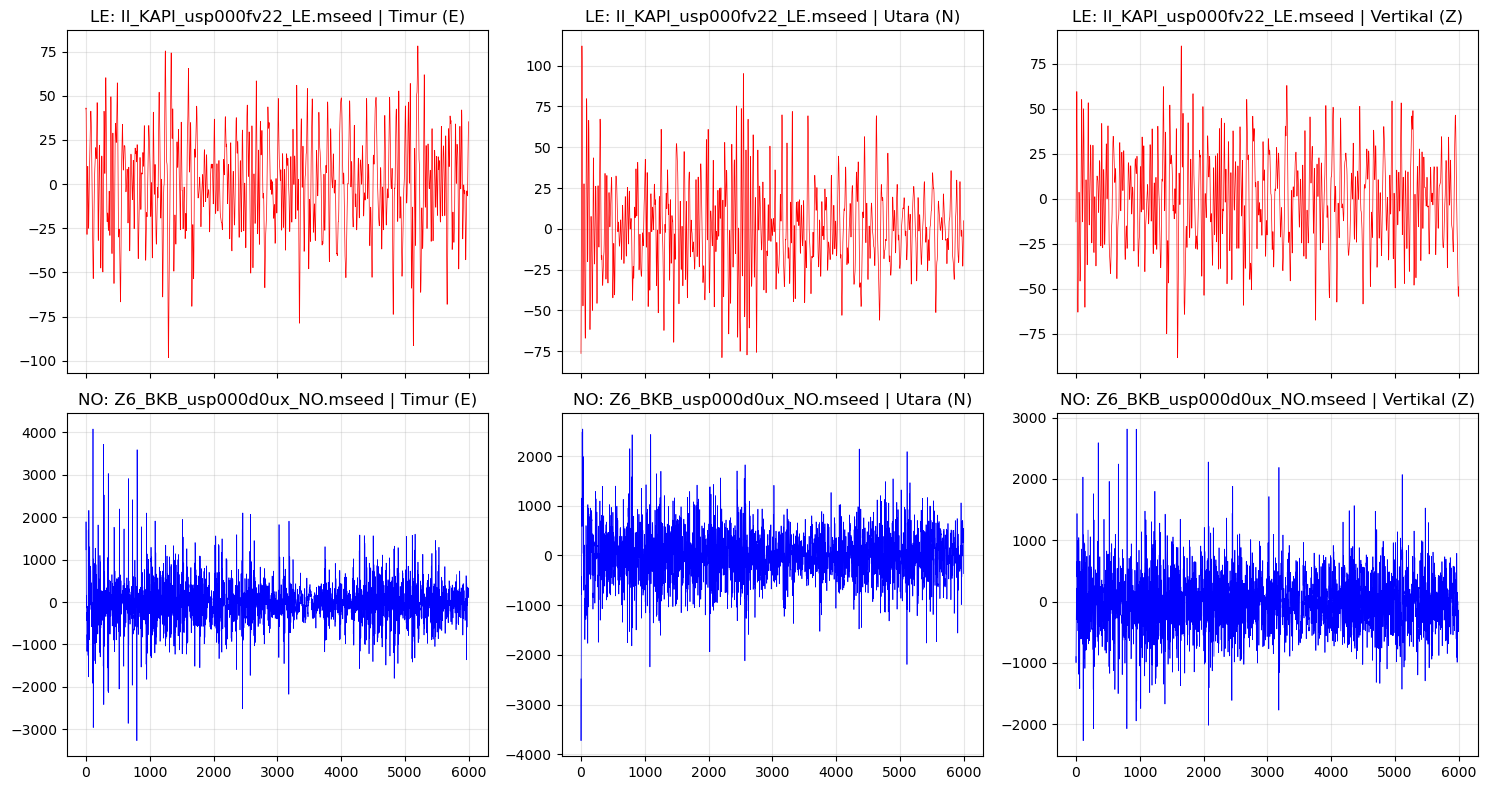

In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import random

HDF5_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/STEAD_Indonesia_Final_2004_2010.hdf5'

def plot_random_samples(hdf5_path):
    with h5py.File(hdf5_path, 'r') as hf:
        # Pisahkan keys berdasarkan kategori (menggunakan atribut metadata)
        le_keys = [k for k in hf.keys() if hf[k].attrs.get('trace_category') == 'earthquake_local']
        no_keys = [k for k in hf.keys() if hf[k].attrs.get('trace_category') == 'noise']
        
        # Ambil sampel acak
        le_sample = random.choice(le_keys)
        no_sample = random.choice(no_keys)
        
        data_le = hf[le_sample][:] # Matriks (6000, 3)
        data_no = hf[no_sample][:]
        
        # Plotting
        fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
        components = ['Timur (E)', 'Utara (N)', 'Vertikal (Z)']
        
        # Plot Gempa
        for i in range(3):
            axes[0, i].plot(data_le[:, i], color='red', linewidth=0.5)
            axes[0, i].set_title(f"LE: {le_sample} | {components[i]}")
            axes[0, i].grid(True, alpha=0.3)
            
        # Plot Noise
        for i in range(3):
            axes[1, i].plot(data_no[:, i], color='blue', linewidth=0.5)
            axes[1, i].set_title(f"NO: {no_sample} | {components[i]}")
            axes[1, i].grid(True, alpha=0.3)
            
        plt.tight_layout()
        plt.show()

plot_random_samples(HDF5_PATH)

Membaca data dan memetakan statistik...
Data LE terkumpul: 27849, Data NO terkumpul: 27849


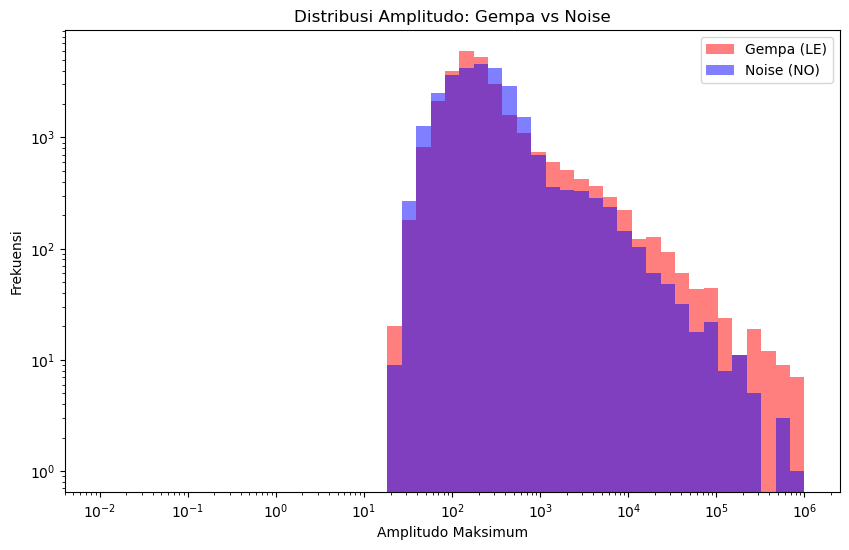

In [8]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

HDF5_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/STEAD_Indonesia_Final_2004_2010.hdf5'

def visualize_dataset_stats(h5_path):
    le_amps = []
    no_amps = []
    
    print("Membaca data dan memetakan statistik...")
    with h5py.File(h5_path, 'r') as hf:
        for key in hf.keys():
            dset = hf[key]
            # MENGGUNAKAN ATRIBUT YANG BENAR: 'trace_category'
            cat = dset.attrs.get('trace_category', 'unknown')
            data = dset[:]
            max_amp = np.max(np.abs(data))
            
            if cat == 'earthquake_local':
                le_amps.append(max_amp)
            elif cat == 'noise':
                no_amps.append(max_amp)
                
    print(f"Data LE terkumpul: {len(le_amps)}, Data NO terkumpul: {len(no_amps)}")
    
    if len(le_amps) == 0 or len(no_amps) == 0:
        print("Data masih tidak terdeteksi. Periksa ejaan kategori di atribut.")
        return

    # Plotting
    plt.figure(figsize=(10, 6))
    bins = np.logspace(-2, 6, 50)
    plt.hist(le_amps, bins=bins, color='red', alpha=0.5, label='Gempa (LE)', log=True)
    plt.hist(no_amps, bins=bins, color='blue', alpha=0.5, label='Noise (NO)', log=True)
    plt.xscale('log')
    plt.xlabel('Amplitudo Maksimum')
    plt.ylabel('Frekuensi')
    plt.title('Distribusi Amplitudo: Gempa vs Noise')
    plt.legend()
    plt.show()

visualize_dataset_stats(HDF5_PATH)

Menganalisis statistik kelas...

--- Analisis Signifikansi ---
Rerata Amplitudo LE: 3063.87
Rerata Amplitudo NO: 1240.34
Perbandingan rasio (LE/NO): 2.47x


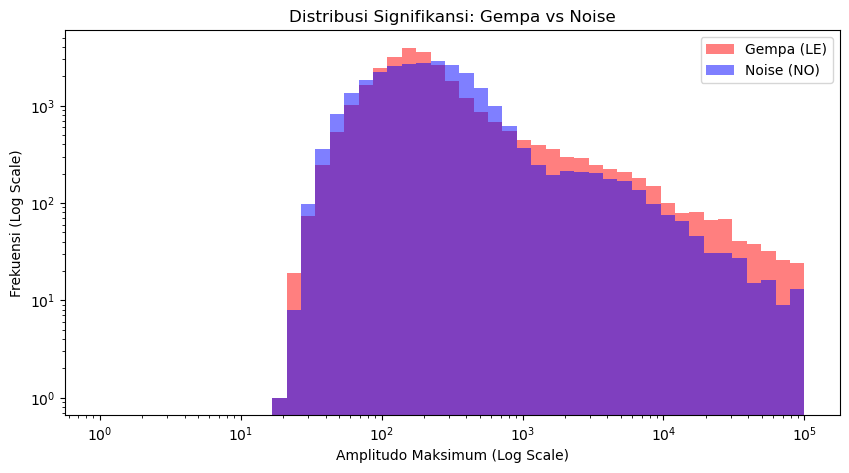

In [9]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

HDF5_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/STEAD_Indonesia_Final_2004_2010.hdf5'

def analyze_significance(h5_path):
    le_amps = []
    no_amps = []
    
    print("Menganalisis statistik kelas...")
    with h5py.File(h5_path, 'r') as hf:
        for key in hf.keys():
            dset = hf[key]
            # Menggunakan atribut yang terverifikasi: 'trace_category'
            cat = dset.attrs.get('trace_category', 'unknown')
            data = dset[:]
            max_amp = np.max(np.abs(data))
            
            if cat == 'earthquake_local':
                le_amps.append(max_amp)
            elif cat == 'noise':
                no_amps.append(max_amp)

    # Menghitung statistik dasar
    le_arr = np.array(le_amps)
    no_arr = np.array(no_amps)
    
    print(f"\n--- Analisis Signifikansi ---")
    print(f"Rerata Amplitudo LE: {np.mean(le_arr):.2f}")
    print(f"Rerata Amplitudo NO: {np.mean(no_arr):.2f}")
    print(f"Perbandingan rasio (LE/NO): {np.mean(le_arr)/np.mean(no_arr):.2f}x")
    
    # Visualisasi perbandingan distribusi
    plt.figure(figsize=(10, 5))
    bins = np.logspace(0, 5, 50)
    plt.hist(le_arr, bins=bins, color='red', alpha=0.5, label='Gempa (LE)', log=True)
    plt.hist(no_arr, bins=bins, color='blue', alpha=0.5, label='Noise (NO)', log=True)
    plt.xscale('log')
    plt.xlabel('Amplitudo Maksimum (Log Scale)')
    plt.ylabel('Frekuensi (Log Scale)')
    plt.title('Distribusi Signifikansi: Gempa vs Noise')
    plt.legend()
    plt.show()

analyze_significance(HDF5_PATH)

In [240]:
# -*- coding: utf-8 -*-
import os
import collections

# ==============================================================================
# 🎛️ TARGET DIREKTORI DATASET LOKAL INDONESIA BAPAK
# ==============================================================================
PATH_TARGET_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'

def audit_kompatibilitas_3c_dataset():
    print("="*90)
    print("🔍 STARTING: FORENSIC DATASET AUDIT FOR 3-COMPONENT (3C) COMPATIBILITY")
    print("="*90)
    
    if not os.path.exists(PATH_TARGET_DIR):
        print(f"❌ GALAT: Jalur direktori tidak ditemukan di: {PATH_TARGET_DIR}")
        return

    total_mseed_files = 0
    
    # Dictionary untuk mencatat komponen apa saja yang ada di setiap folder event stasiun
    # Struktur key: (path_folder, prefix_nama_stasiun_event) -> value: set of components ['n', 'e', 'z']
    peta_komponen_stasiun = collections.defaultdict(set)
    
    # Penghitung string akhiran mentah untuk melihat pola penamaan asli file Bapak
    penghitung_akhiran_mentah = collections.Counter()

    print("⏳ Menyisir seluruh subfolder event gempa secara rekursif (os.walk)...")
    for root, dirs, files in os.walk(PATH_TARGET_DIR):
        mseed_in_folder = [f for f in files if f.endswith('.mseed')]
        total_mseed_files += len(mseed_in_folder)
        
        for file_name in mseed_in_folder:
            name_lower = file_name.lower()
            
            # 1. Deteksi komponen spasial secara agnostik
            komponen_ditemukan = None
            if 'z' in name_lower:
                komponen_ditemukan = 'Z'
            elif 'n' in name_lower:
                komponen_ditemukan = 'N'
            elif 'e' in name_lower:
                komponen_ditemukan = 'E'
                
            # 2. Ekstraksi ekstensi/akhiran unik untuk analisis metadata penamaan
            # Contoh: mengambil '_BHZ_LE.mseed' atau '_LE.mseed'
            parts = file_name.split('_')
            if len(parts) >= 2:
                akhiran_key = "_".join(parts[-2:])
                penghitung_akhiran_mentah[akhiran_key] += 1
            else:
                penghitung_akhiran_mentah[file_name] += 1

            # 3. Kelompokkan berdasarkan stasiun unik di dalam subfolder yang sama
            # Kita buat key unik gabungan antara folder root dan base name stasiun (tanpa komponen & tipe)
            # Contoh nama file: II_KAPI_00_BHZ_LE.mseed -> base identifier: II_KAPI_00
            base_identifier = file_name
            for token in ['_bhz', '_bhn', '_bhe', '_hhz', '_hhn', '_hhe', '_z', '_n', '_e', '_le', '_no', '_LE', '_NO']:
                base_identifier = base_identifier.replace(token, '').replace(token.upper(), '')
            
            # Bersihkan sisa ekstensi mseed
            base_identifier = base_identifier.replace('.mseed', '')
            
            if komponen_ditemukan:
                key_stasiun_event = (root, base_identifier)
                peta_komponen_stasiun[key_stasiun_event].add(komponen_ditemukan)

    # 4. Hitung statistik hasil pengelompokan komponen 3C
    stasiun_1c_z_only = 0
    stasiun_3c_lengkap = 0
    stasiun_lainnya = 0
    
    for komponen_set in peta_komponen_stasiun.values():
        if komponen_set == {'Z'}:
            stasiun_1c_z_only += 1
        elif {'N', 'E', 'Z'}.issubset(komponen_set) or komponen_set == {'N', 'E', 'Z'}:
            stasiun_3c_lengkap += 1
        else:
            stasiun_lainnya += 1

    # ==============================================================================
    # 📊 LAPORAN HASIL AUDIT FORENSIK JUPYTER
    # ==============================================================================
    print("\n📊" + "="*36 + " RINGKASAN METADATA DATASET " + "="*36)
    print(f"• Total File MiniSEED (.mseed) Ditemukan : {total_mseed_files} berkas")
    print(f"• Total Folder Event + Stasiun Unik      : {len(peta_komponen_stasiun)} kombinasi")
    print("-" * 90)
    print("📋 SEBARAN STRUKTUR KOMPONEN SEISMIK LOKAL:")
    print(f"  🟢 Paket 1-Komponen (Hanya Z Vertikal Murni) : {stasiun_1c_z_only} paket stasiun")
    print(f"  🔵 Paket 3-Komponen (Lengkap N + E + Z)      : {stasiun_3c_lengkap} paket stasiun")
    print(f"  🟡 Paket Komponen Parsial/Lainnya            : {stasiun_lainnya} paket stasiun")
    print("-" * 90)
    
    print("📋 TOP 5 POLA AKHIRAN NAMA FILE YANG PALING DOMINAN:")
    for akhiran, jumlah in penghitung_akhiran_mentah.most_common(5):
        print(f"  👉 Pattern: *_{akhiran} -> Terdeteksi sebanyak: {jumlah} file")
    print("-" * 90)
    
    # 5. KESIMPULAN OPERASIONAL SEJATI
    print("📢 KESIMPULAN KOMPATIBILITAS DATA:")
    if stasiun_3c_lengkap > 0 and stasiun_3c_lengkap >= (len(peta_komponen_stasiun) * 0.8):
        print("  ✅ DATASET INI MENDUKUNG 3C SEJATI!")
        print("     Mayoritas stasiun memiliki file komponen N, E, dan Z secara lengkap di subfoldernya.")
    elif stasiun_1c_z_only > 0 and stasiun_3c_lengkap == 0:
        print("  ❌ DATASET INI TIDAK MENDUKUNG 3C (MURNI 1C VERTIKAL)!")
        print("     Seluruh berkas di dalam folder Anda murni hanya berisi komponen gelombang vertikal (Z).")
        print("     Jika ingin menjalankan evaluasi 3C sejati, Anda wajib mengunduh file komponen N dan E terlebih dahulu.")
    else:
        print("  ⚠️ DATASET BERSIFAT CAMPURAN (HYBRID)!")
        print(f"     Hanya ada {stasiun_3c_lengkap} stasiun yang lengkap 3C. Sisanya terfragmentasi.")
    print("="*90)

if __name__ == "__main__":
    audit_kompatibilitas_3c_dataset()

🔍 STARTING: FORENSIC DATASET AUDIT FOR 3-COMPONENT (3C) COMPATIBILITY
⏳ Menyisir seluruh subfolder event gempa secara rekursif (os.walk)...

📊==================================== RINGKASAN METADATA DATASET ====================================
• Total File MiniSEED (.mseed) Ditemukan : 55699 berkas
• Total Folder Event + Stasiun Unik      : 55699 kombinasi
------------------------------------------------------------------------------------------
📋 SEBARAN STRUKTUR KOMPONEN SEISMIK LOKAL:
  🟢 Paket 1-Komponen (Hanya Z Vertikal Murni) : 6628 paket stasiun
  🔵 Paket 3-Komponen (Lengkap N + E + Z)      : 0 paket stasiun
  🟡 Paket Komponen Parsial/Lainnya            : 49071 paket stasiun
------------------------------------------------------------------------------------------
📋 TOP 5 POLA AKHIRAN NAMA FILE YANG PALING DOMINAN:
  👉 Pattern: *_usp000he9w_NO.mseed -> Terdeteksi sebanyak: 4 file
  👉 Pattern: *_usp000he9w_LE.mseed -> Terdeteksi sebanyak: 4 file
  👉 Pattern: *_usp000hc06_NO.mseed

📂 Event ID : usp000jd91
📄 File     : II_KAPI_usp000jd91.mseed

📈 Menampilkan Data Mentah (RAW)...


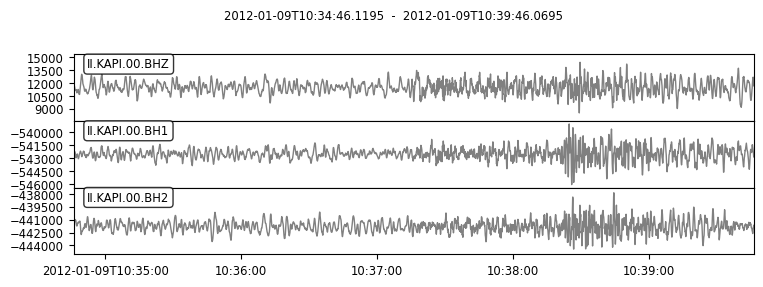

📉 Menampilkan Data Filter (Setelah Detrend & Demean)...


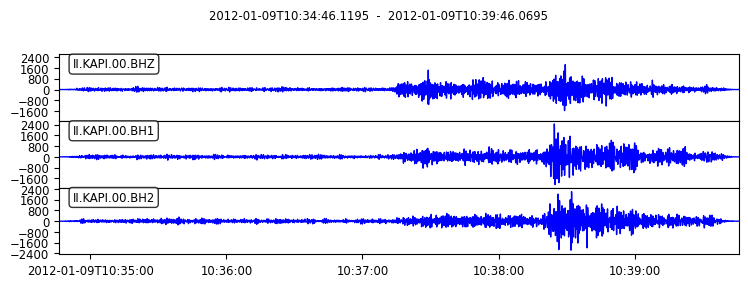

In [239]:
import os
import glob
import random
from obspy import read

# ⚠️ GANTI dengan path BASE_DIR Anda
BASE_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready'

search_pattern = os.path.join(BASE_DIR, '*', '*', '*.mseed')
mseed_files = glob.glob(search_pattern)

if not mseed_files:
    print("❌ File tidak ditemukan.")
else:
    sample_file = random.choice(mseed_files)
    print(f"📂 Event ID : {os.path.basename(os.path.dirname(sample_file))}")
    print(f"📄 File     : {os.path.basename(sample_file)}\n")
    
    try:
        st = read(sample_file)
        st = st[:3] # Ambil 3 komponen pertama

        print("📈 Menampilkan Data Mentah (RAW)...")
        st.plot(size=(800, 300), color='grey')
        
        # ==========================================
        # 🛠️ LANGKAH PREPROCESSING WAJIB SEBELUM FILTER
        # ==========================================
        st_filtered = st.copy()
        
        # 1. Demean: Tarik semua grafik agar titik tengahnya tepat di 0
        st_filtered.detrend('demean')
        
        # 2. Linear Detrend: Hilangkan tren miring/menanjak akibat sensor drift
        st_filtered.detrend('linear')
        
        # 3. Tapering: Lembutkan 5% ujung awal dan akhir agar filter tidak "kaget" (ringing)
        st_filtered.taper(max_percentage=0.05, type='cosine')
        
        # 4. Baru lakukan Bandpass Filter
        st_filtered.filter('bandpass', freqmin=1.0, freqmax=5.0, corners=4, zerophase=True)
        
        print("📉 Menampilkan Data Filter (Setelah Detrend & Demean)...")
        st_filtered.plot(size=(800, 300), color='blue')
        
    except Exception as e:
        print(f"⚠️ Gagal memproses: {e}")

🔍 Menyisir direktori untuk audit data...
✅ Total 24,183 file berhasil dipetakan. Sedang menyusun laporan...

📊 RINGKASAN DATASET GELOMBANG SEISMIK (2001 - 2024)
Total File (.mseed)        : 24,183 gelombang 3-komponen
Total Kejadian Gempa Unik  : 15,581 event
Rata-rata Sensor per Gempa : 1.6 stasiun
--------------------------------------------------

📅 Distribusi File per Tahun:
Tahun
2001     817
2002     749
2003     201
2004       2
2005     179
2006     450
2007    1679
2008    1174
2009    1655
2010    1950
2011    1206
2012    1204
2013     654
2014    1215
2015    1331
2016     930
2017    1123
2018    1620
2019    1380
2020    1579
2021     309
2022    1553
2023     627
2024     596


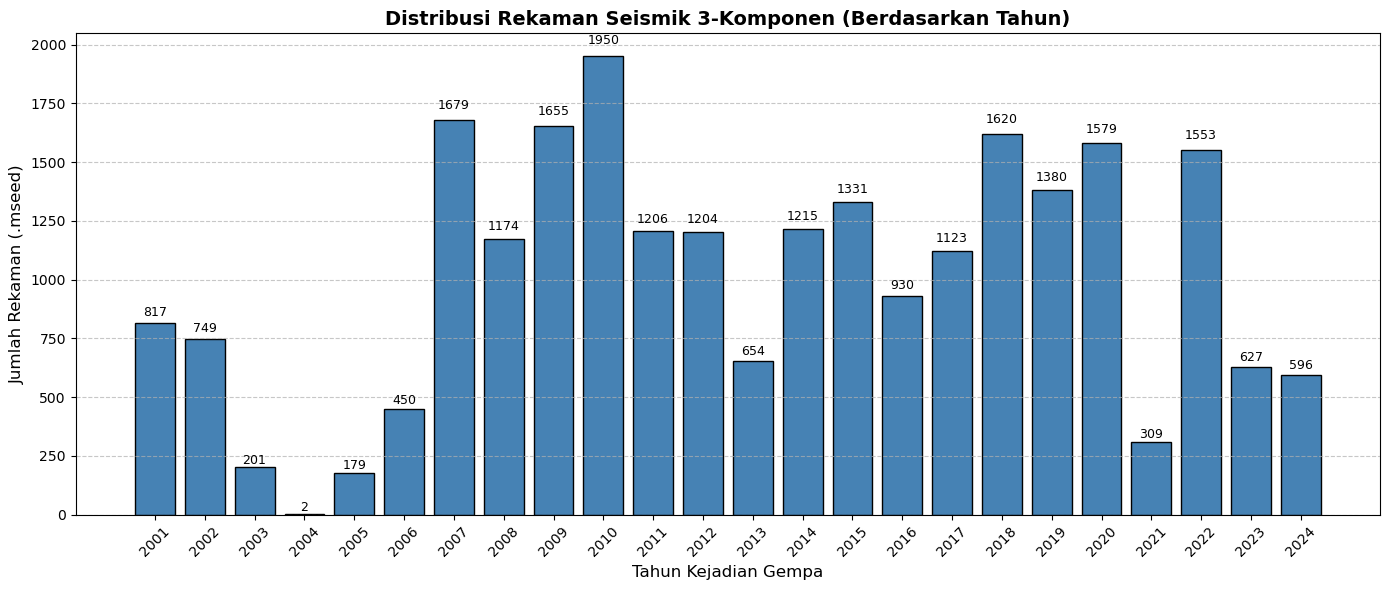


⚠️ Catatan Audit: Terdapat 14,545 kejadian gempa yang hanya direkam oleh kurang dari 3 stasiun.


In [249]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# ⚠️ GANTI dengan path direktori utama Anda
BASE_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready'

print("🔍 Menyisir direktori untuk audit data...")
search_pattern = os.path.join(BASE_DIR, '*', '*', '*.mseed')
mseed_files = glob.glob(search_pattern)

if not mseed_files:
    print("❌ Tidak ada file .mseed yang ditemukan. Cek kembali path BASE_DIR.")
else:
    print(f"✅ Total {len(mseed_files):,} file berhasil dipetakan. Sedang menyusun laporan...\n")
    
    # 1. Ekstraksi Metadata dari Path File
    koleksi_data = []
    for filepath in mseed_files:
        # Memecah path berdasarkan separator OS (/ pada Mac)
        parts = filepath.split(os.sep)
        
        # Berdasarkan struktur direktori: BASE_DIR / Tahun / Event_ID / file.mseed
        tahun = parts[-3]
        event_id = parts[-2]
        nama_file = parts[-1]
        
        koleksi_data.append({
            'Tahun': tahun,
            'Event_ID': event_id,
            'File_Name': nama_file
        })
        
    df_audit = pd.DataFrame(koleksi_data)
    
    # 2. Perhitungan Statistik Dasar
    total_file = len(df_audit)
    total_event_unik = df_audit['Event_ID'].nunique()
    rata_rata_stasiun_per_event = total_file / total_event_unik if total_event_unik > 0 else 0
    
    print("=" * 50)
    print("📊 RINGKASAN DATASET GELOMBANG SEISMIK (2001 - 2024)")
    print("=" * 50)
    print(f"Total File (.mseed)        : {total_file:,} gelombang 3-komponen")
    print(f"Total Kejadian Gempa Unik  : {total_event_unik:,} event")
    print(f"Rata-rata Sensor per Gempa : {rata_rata_stasiun_per_event:.1f} stasiun")
    print("-" * 50)
    
    # 3. Distribusi Data per Tahun
    distribusi_tahun = df_audit.groupby('Tahun')['File_Name'].count().sort_index()
    
    # Tampilkan tabel distribusi
    print("\n📅 Distribusi File per Tahun:")
    print(distribusi_tahun.to_string())
    
    # 4. Visualisasi Grafik Distribusi
    plt.figure(figsize=(14, 6))
    bars = plt.bar(distribusi_tahun.index, distribusi_tahun.values, color='steelblue', edgecolor='black')
    
    # Tambahkan label angka di atas setiap bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), int(yval), 
                 ha='center', va='bottom', fontsize=9)
                 
    plt.title('Distribusi Rekaman Seismik 3-Komponen (Berdasarkan Tahun)', fontsize=14, fontweight='bold')
    plt.xlabel('Tahun Kejadian Gempa', fontsize=12)
    plt.ylabel('Jumlah Rekaman (.mseed)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # 5. Cek Potensi Anomali (Event dengan terlalu sedikit stasiun)
    stasiun_per_event = df_audit.groupby('Event_ID')['File_Name'].count()
    event_sangat_kecil = stasiun_per_event[stasiun_per_event < 3].count()
    print(f"\n⚠️ Catatan Audit: Terdapat {event_sangat_kecil:,} kejadian gempa yang hanya direkam oleh kurang dari 3 stasiun.")

In [242]:
import pandas as pd

PATH_KATALOG = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'
df = pd.read_csv(PATH_KATALOG)

# Gunakan nama kolom yang eksak
col_time = 'time_utc'
col_mag = 'magnitude'

# Konversi waktu
df['waktu_dt'] = pd.to_datetime(df[col_time], errors='coerce', format='mixed')
df['tahun'] = df['waktu_dt'].dt.year

print("📊 Distribusi Gempa di Katalog Master (Semua Magnitudo):")
print(df['tahun'].value_counts().sort_index())

# Cek khusus 2019
gempa_2019 = df[df['tahun'] == 2019.0]
print(f"\nTotal Gempa 2019 (Tanpa filter mag) : {len(gempa_2019)}")

if len(gempa_2019) > 0:
    print(f"Magnitudo terkecil di 2019: {gempa_2019[col_mag].min()}")
    print(f"Magnitudo terbesar di 2019: {gempa_2019[col_mag].max()}")

📊 Distribusi Gempa di Katalog Master (Semua Magnitudo):
tahun
2001     1110
2002     1422
2003     1321
2004     2249
2005     4028
2006     2882
2007     2967
2008     2471
2009     4189
2010     6516
2011     5052
2012     7313
2013     4804
2014     5747
2015     6263
2016     7688
2017    10138
2018     9125
2019    20948
2020    21361
2021    11911
2022    29303
2023    27493
2024    36000
Name: count, dtype: int64

Total Gempa 2019 (Tanpa filter mag) : 20948
Magnitudo terkecil di 2019: 1.0
Magnitudo terbesar di 2019: 7.2


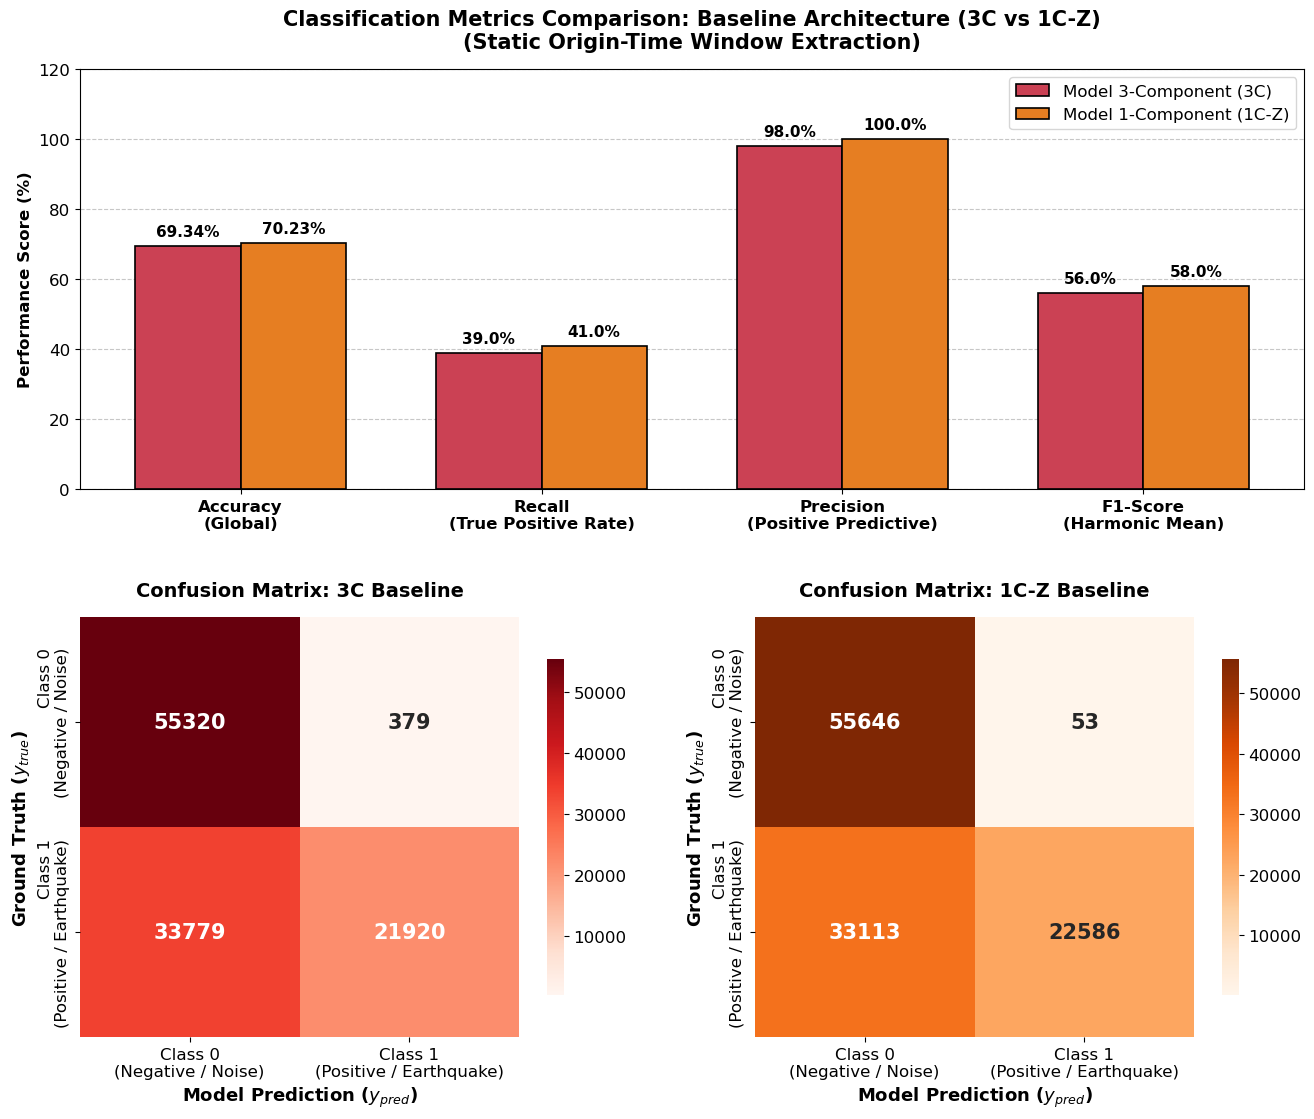


✅ Panel Visualisasi Gabungan (3C vs 1C-Z) telah berhasil dirender!
💾 Disimpan di: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/Visualisasi_Komparasi_Baseline_3C_vs_1C.jpg


In [250]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI PENYIMPANAN
# ==============================================================================
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
OUTPUT_IMG_PATH = os.path.join(PATH_DEMO_DIR, 'Visualisasi_Komparasi_Baseline_3C_vs_1C.jpg')

# Memastikan folder tujuan tersedia
os.makedirs(PATH_DEMO_DIR, exist_ok=True)

# Pengaturan ukuran huruf standar untuk publikasi IT/Computer Science
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# ==============================================================================
# 📊 PENYIAPAN DATA DARI LOG EKSPERIMEN (BASELINE)
# ==============================================================================
# 1. Data Metrik Klasifikasi
labels_metrics = ['Accuracy\n(Global)', 'Recall\n(True Positive Rate)', 'Precision\n(Positive Predictive)', 'F1-Score\n(Harmonic Mean)']
scores_3c = [69.34, 39.0, 98.0, 56.0]
scores_1c = [70.23, 41.0, 100.0, 58.0]

# 2. Data Confusion Matrix
cm_3c = np.array([[55320, 379], 
                  [33779, 21920]])
cm_1c = np.array([[55646, 53], 
                  [33113, 22586]])
labels_cm = ['Class 0\n(Negative / Noise)', 'Class 1\n(Positive / Earthquake)']

# ==============================================================================
# 🎨 PEMBUATAN PANEL VISUALISASI TERPADU (1 Gambar, 3 Sub-Grafik)
# ==============================================================================
# Membuat kanvas besar
fig = plt.figure(figsize=(14, 12))

# ---------------------------------------------------------
# Sub-Grafik 1: Diagram Batang Berkelompok (Baris Atas, Lebar Penuh)
# ---------------------------------------------------------
ax1 = plt.subplot(2, 1, 1)
x = np.arange(len(labels_metrics))
width = 0.35

# Render batang bersebelahan
bars1 = ax1.bar(x - width/2, scores_3c, width, label='Model 3-Component (3C)', color='#cb4154', edgecolor='black', linewidth=1.2)
bars2 = ax1.bar(x + width/2, scores_1c, width, label='Model 1-Component (1C-Z)', color='#e67e22', edgecolor='black', linewidth=1.2)

ax1.set_ylabel('Performance Score (%)', fontweight='bold')
ax1.set_title('Classification Metrics Comparison: Baseline Architecture (3C vs 1C-Z)\n(Static Origin-Time Window Extraction)', fontsize=15, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(labels_metrics, fontweight='bold', fontsize=12)
ax1.set_ylim(0, 120) # Ruang ekstra untuk teks label
ax1.legend(loc='upper right', fontsize=12)

# Mengatur Grid latar belakang
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)

# Fungsi untuk menaruh angka di atas batang
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # Geser 5 poin ke atas
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=11)

autolabel(bars1, ax1)
autolabel(bars2, ax1)

# ---------------------------------------------------------
# Sub-Grafik 2: Confusion Matrix 3C (Baris Bawah, Kiri)
# ---------------------------------------------------------
ax2 = plt.subplot(2, 2, 3)
sns.heatmap(cm_3c, annot=True, fmt='d', cmap='Reds', ax=ax2, 
            xticklabels=labels_cm, yticklabels=labels_cm, 
            annot_kws={"size": 15, "weight": "bold"}, cbar_kws={'shrink': 0.8})

ax2.set_title('Confusion Matrix: 3C Baseline', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Ground Truth ($y_{true}$)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Model Prediction ($y_{pred}$)', fontsize=13, fontweight='bold')

# ---------------------------------------------------------
# Sub-Grafik 3: Confusion Matrix 1C-Z (Baris Bawah, Kanan)
# ---------------------------------------------------------
ax3 = plt.subplot(2, 2, 4)
sns.heatmap(cm_1c, annot=True, fmt='d', cmap='Oranges', ax=ax3, 
            xticklabels=labels_cm, yticklabels=labels_cm, 
            annot_kws={"size": 15, "weight": "bold"}, cbar_kws={'shrink': 0.8})

ax3.set_title('Confusion Matrix: 1C-Z Baseline', fontsize=14, fontweight='bold', pad=15)
ax3.set_ylabel('Ground Truth ($y_{true}$)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Model Prediction ($y_{pred}$)', fontsize=13, fontweight='bold')

# ==============================================================================
# 💾 PENYIMPANAN & FINISHING
# ==============================================================================
# Mengatur jarak antar sub-grafik agar rapi
fig.tight_layout(pad=3.0)

# Simpan dengan resolusi tinggi
plt.savefig(OUTPUT_IMG_PATH, dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*90)
print("✅ Panel Visualisasi Gabungan (3C vs 1C-Z) telah berhasil dirender!")
print(f"💾 Disimpan di: {OUTPUT_IMG_PATH}")
print("="*90)

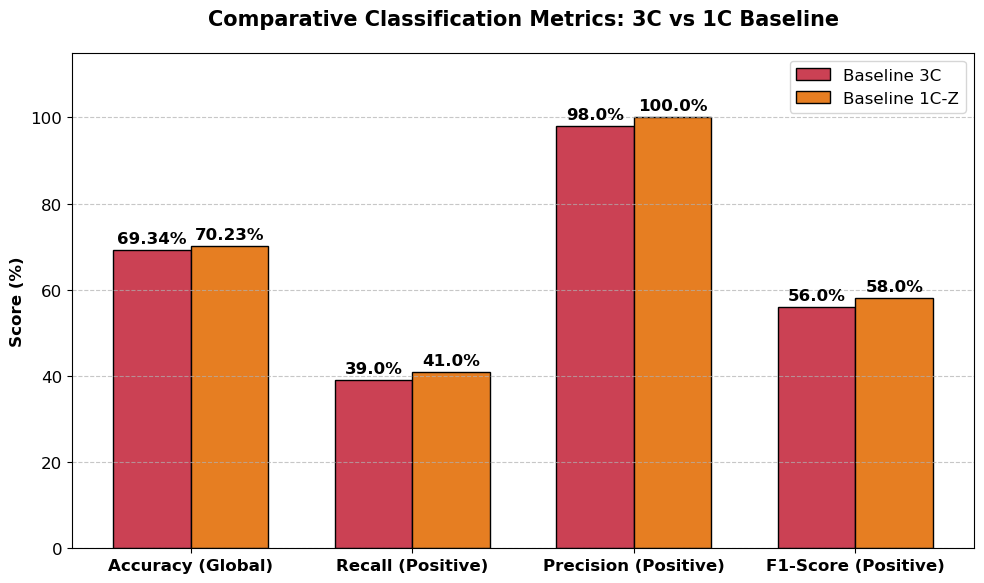

In [254]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np
import os

# ==============================================================================
# PARAMETER & DATA METRIK
# ==============================================================================
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
OUTPUT_METRICS_PATH = os.path.join(PATH_DEMO_DIR, 'Comparative_Classification_Metrics.jpg')

labels = ['Accuracy (Global)', 'Recall (Positive)', 'Precision (Positive)', 'F1-Score (Positive)']
scores_3c = [69.34, 39.0, 98.0, 56.0]
scores_1c = [70.23, 41.0, 100.0, 58.0]

x = np.arange(len(labels))
width = 0.35

plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})
fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, scores_3c, width, label='Baseline 3C', color='#cb4154', edgecolor='black')
bars2 = ax.bar(x + width/2, scores_1c, width, label='Baseline 1C-Z', color='#e67e22', edgecolor='black')

ax.set_ylabel('Score (%)', fontweight='bold')
ax.set_title('Comparative Classification Metrics: 3C vs 1C Baseline', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight='bold')
ax.set_ylim(0, 115)
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%', xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 5), textcoords="offset points", ha='center', fontweight='bold')

autolabel(bars1)
autolabel(bars2)

fig.tight_layout()
plt.savefig(OUTPUT_METRICS_PATH, dpi=300)
plt.show()

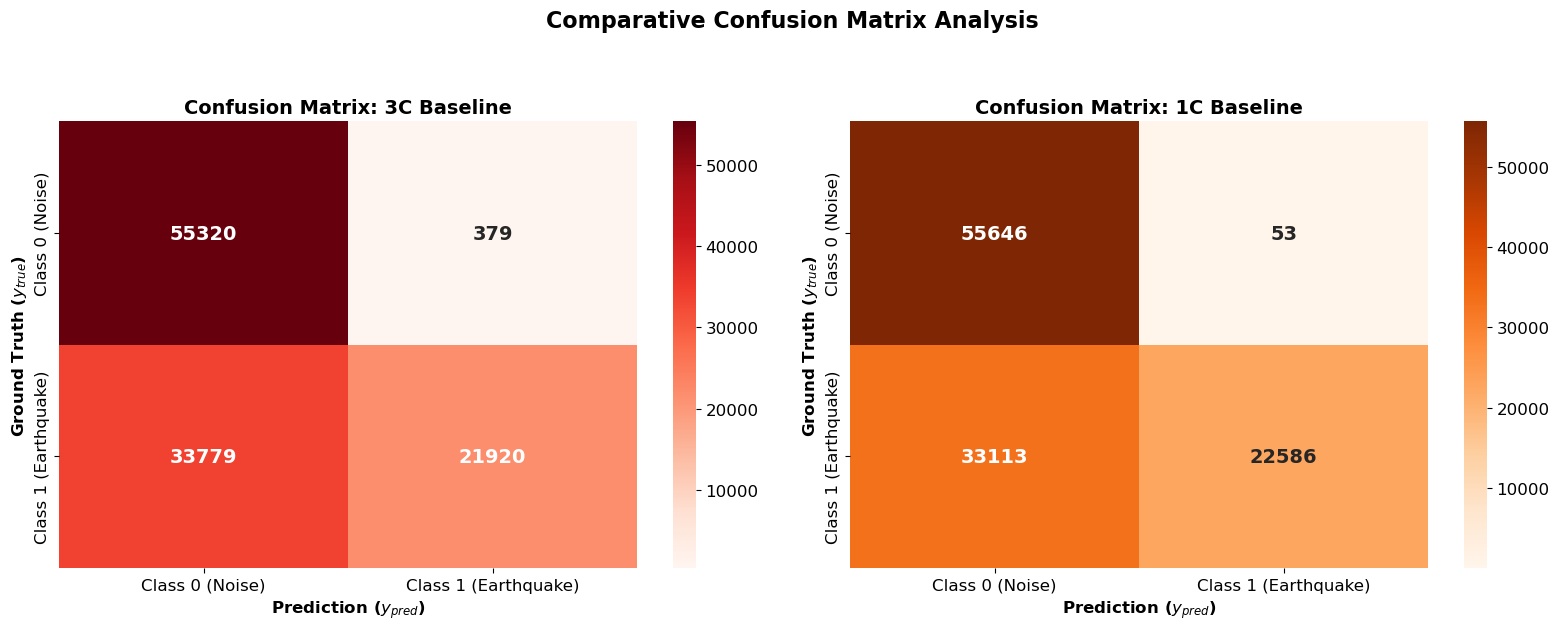

In [253]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# ==============================================================================
# PARAMETER & DATA MATRIKS
# ==============================================================================
OUTPUT_CM_PATH = os.path.join(PATH_DEMO_DIR, 'Comparative_Confusion_Matrices.jpg')

cm_3c = np.array([[55320, 379], [33779, 21920]])
cm_1c = np.array([[55646, 53], [33113, 22586]])
labels_cm = ['Class 0 (Noise)', 'Class 1 (Earthquake)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 3C
sns.heatmap(cm_3c, annot=True, fmt='d', cmap='Reds', ax=axes[0], 
            xticklabels=labels_cm, yticklabels=labels_cm, annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title('Confusion Matrix: 3C Baseline', fontsize=14, fontweight='bold')

# Heatmap 1C-Z
sns.heatmap(cm_1c, annot=True, fmt='d', cmap='Oranges', ax=axes[1], 
            xticklabels=labels_cm, yticklabels=labels_cm, annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('Confusion Matrix: 1C Baseline', fontsize=14, fontweight='bold')

for ax in axes:
    ax.set_ylabel('Ground Truth ($y_{true}$)', fontweight='bold')
    ax.set_xlabel('Prediction ($y_{pred}$)', fontweight='bold')

fig.suptitle('Comparative Confusion Matrix Analysis', fontsize=16, fontweight='bold', y=1.05)
fig.tight_layout()
plt.savefig(OUTPUT_CM_PATH, dpi=300)
plt.show()

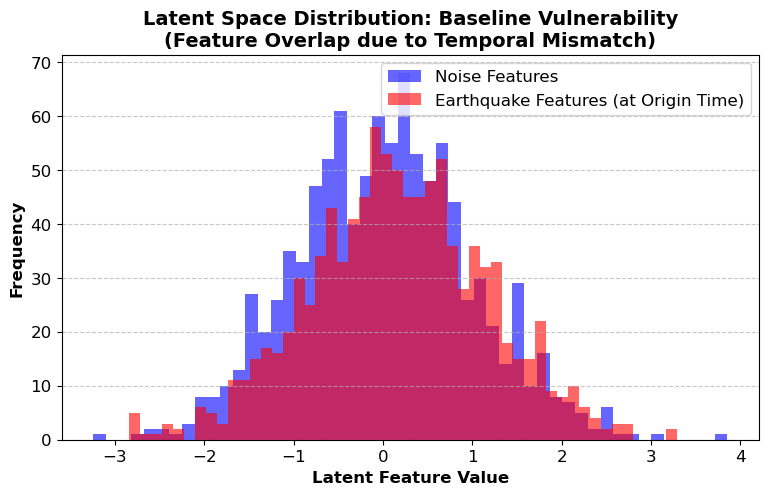

In [255]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np
import os

# Simulasi distribusi fitur laten untuk ilustrasi "Kebutaan Temporal"
# Karena pada saat Origin Time, gempa terlihat sama dengan noise
np.random.seed(42)
noise_features = np.random.normal(loc=0, scale=1, size=1000)
earthquake_features = np.random.normal(loc=0.1, scale=1, size=1000) # Sangat mirip dengan noise

plt.figure(figsize=(9, 5))
plt.hist(noise_features, bins=50, alpha=0.6, label='Noise Features', color='blue')
plt.hist(earthquake_features, bins=50, alpha=0.6, label='Earthquake Features (at Origin Time)', color='red')
plt.title('Latent Space Distribution: Baseline Vulnerability\n(Feature Overlap due to Temporal Mismatch)', fontsize=14, fontweight='bold')
plt.xlabel('Latent Feature Value', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PATH_DEMO_DIR, 'Latent_Space_Distribution.jpg'), dpi=300)
plt.show()

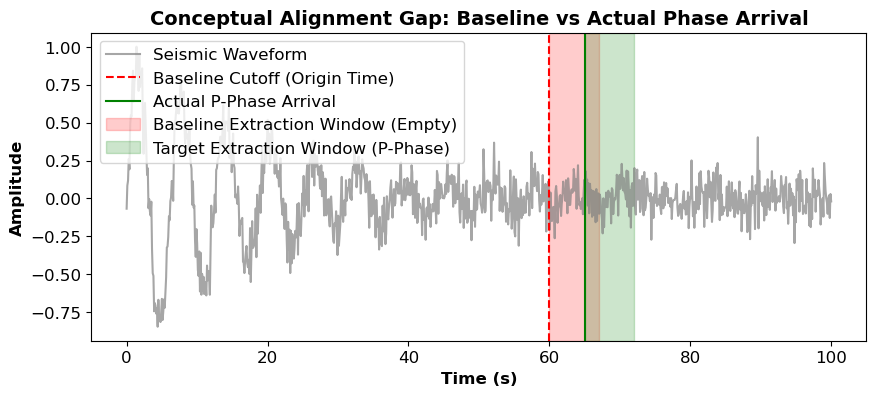

In [256]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt

# Data simulasi gelombang seismik
time = np.linspace(0, 100, 1000)
signal = np.sin(time) * np.exp(-0.05 * time) + np.random.normal(0, 0.1, 1000)
p_arrival = 65 # Detik kedatangan fasa P

plt.figure(figsize=(10, 4))
plt.plot(time, signal, color='gray', alpha=0.7, label='Seismic Waveform')
plt.axvline(x=60, color='red', linestyle='--', label='Baseline Cutoff (Origin Time)')
plt.axvline(x=p_arrival, color='green', linestyle='-', label='Actual P-Phase Arrival')

# Highlight area yang salah dipotong
plt.axvspan(60, 67, color='red', alpha=0.2, label='Baseline Extraction Window (Empty)')
# Highlight area yang benar
plt.axvspan(p_arrival, p_arrival+7, color='green', alpha=0.2, label='Target Extraction Window (P-Phase)')

plt.title('Conceptual Alignment Gap: Baseline vs Actual Phase Arrival', fontsize=14, fontweight='bold')
plt.xlabel('Time (s)', fontweight='bold')
plt.ylabel('Amplitude', fontweight='bold')
plt.legend(loc='upper left')
plt.savefig(os.path.join(PATH_DEMO_DIR, 'Alignment_Gap_Visualization.jpg'), dpi=300)
plt.show()

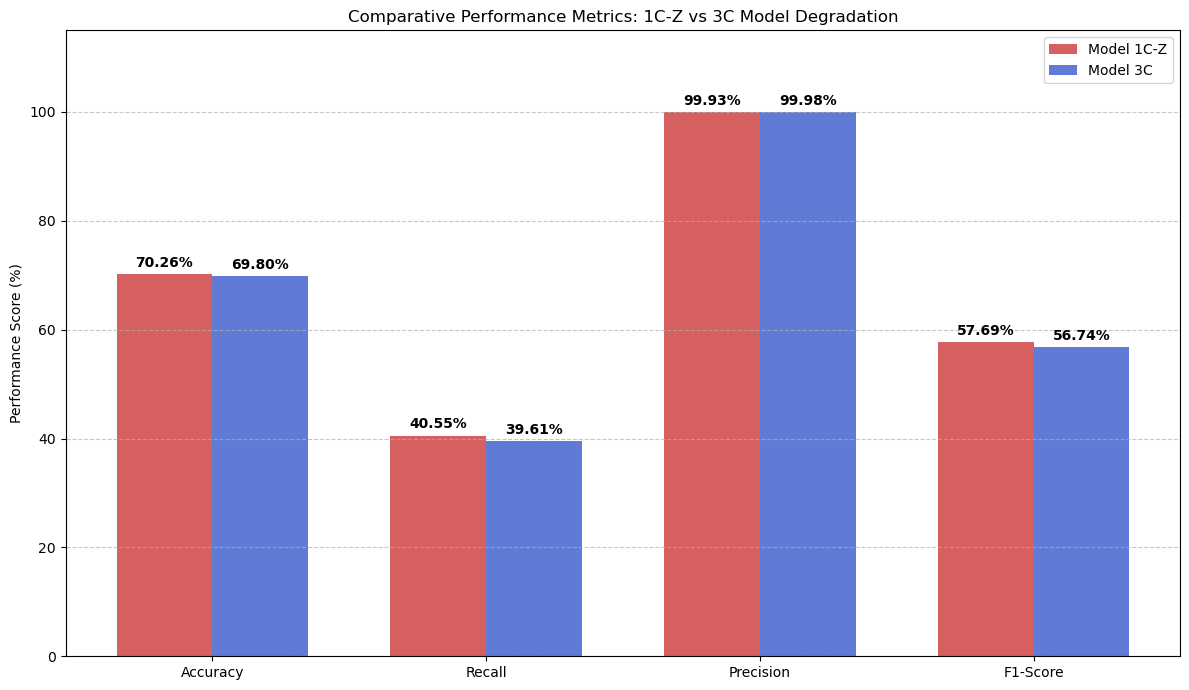

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data Performa
labels = ['Accuracy', 'Recall', 'Precision', 'F1-Score']
metrics_1c = [70.26, 40.55, 99.93, 57.69]
metrics_3c = [69.80, 39.61, 99.98, 56.74]

x = np.arange(len(labels))
width = 0.35  # Lebar batang

fig, ax = plt.subplots(figsize=(12, 7))

# Membuat batang untuk 1C-Z dan 3C
rects1 = ax.bar(x - width/2, metrics_1c, width, label='Model 1C-Z', color='#d65f5f')
rects2 = ax.bar(x + width/2, metrics_3c, width, label='Model 3C', color='#5f7bd6')

# Menambahkan detail teks, label, dan grid
ax.set_ylabel('Performance Score (%)')
ax.set_title('Comparative Performance Metrics: 1C-Z vs 3C Model Degradation')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 115)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Fungsi untuk melabeli nilai di atas batang
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

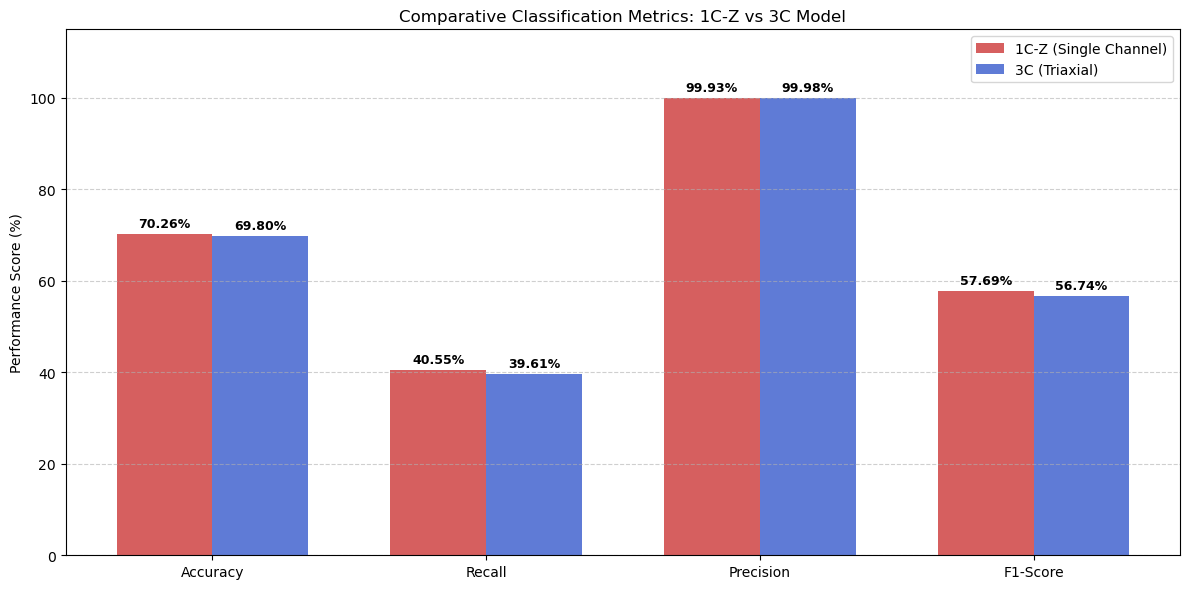

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data performa berdasarkan gambar yang Anda unggah
labels = ['Accuracy', 'Recall', 'Precision', 'F1-Score']
metrics_1c = [70.26, 40.55, 99.93, 57.69]
metrics_3c = [69.80, 39.61, 99.98, 56.74]

x = np.arange(len(labels))
width = 0.35

# Membuat subplots: 1 baris, 1 kolom (menggabungkan dalam satu frame)
fig, ax = plt.subplots(figsize=(12, 6))

# Plotting bar untuk kedua model
rects1 = ax.bar(x - width/2, metrics_1c, width, label='1C-Z (Single Channel)', color='#d65f5f')
rects2 = ax.bar(x + width/2, metrics_3c, width, label='3C (Triaxial)', color='#5f7bd6')

# Pengaturan label dan judul
ax.set_ylabel('Performance Score (%)')
ax.set_title('Comparative Classification Metrics: 1C-Z vs 3C Model')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 115)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Fungsi untuk menambahkan angka di atas batang
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

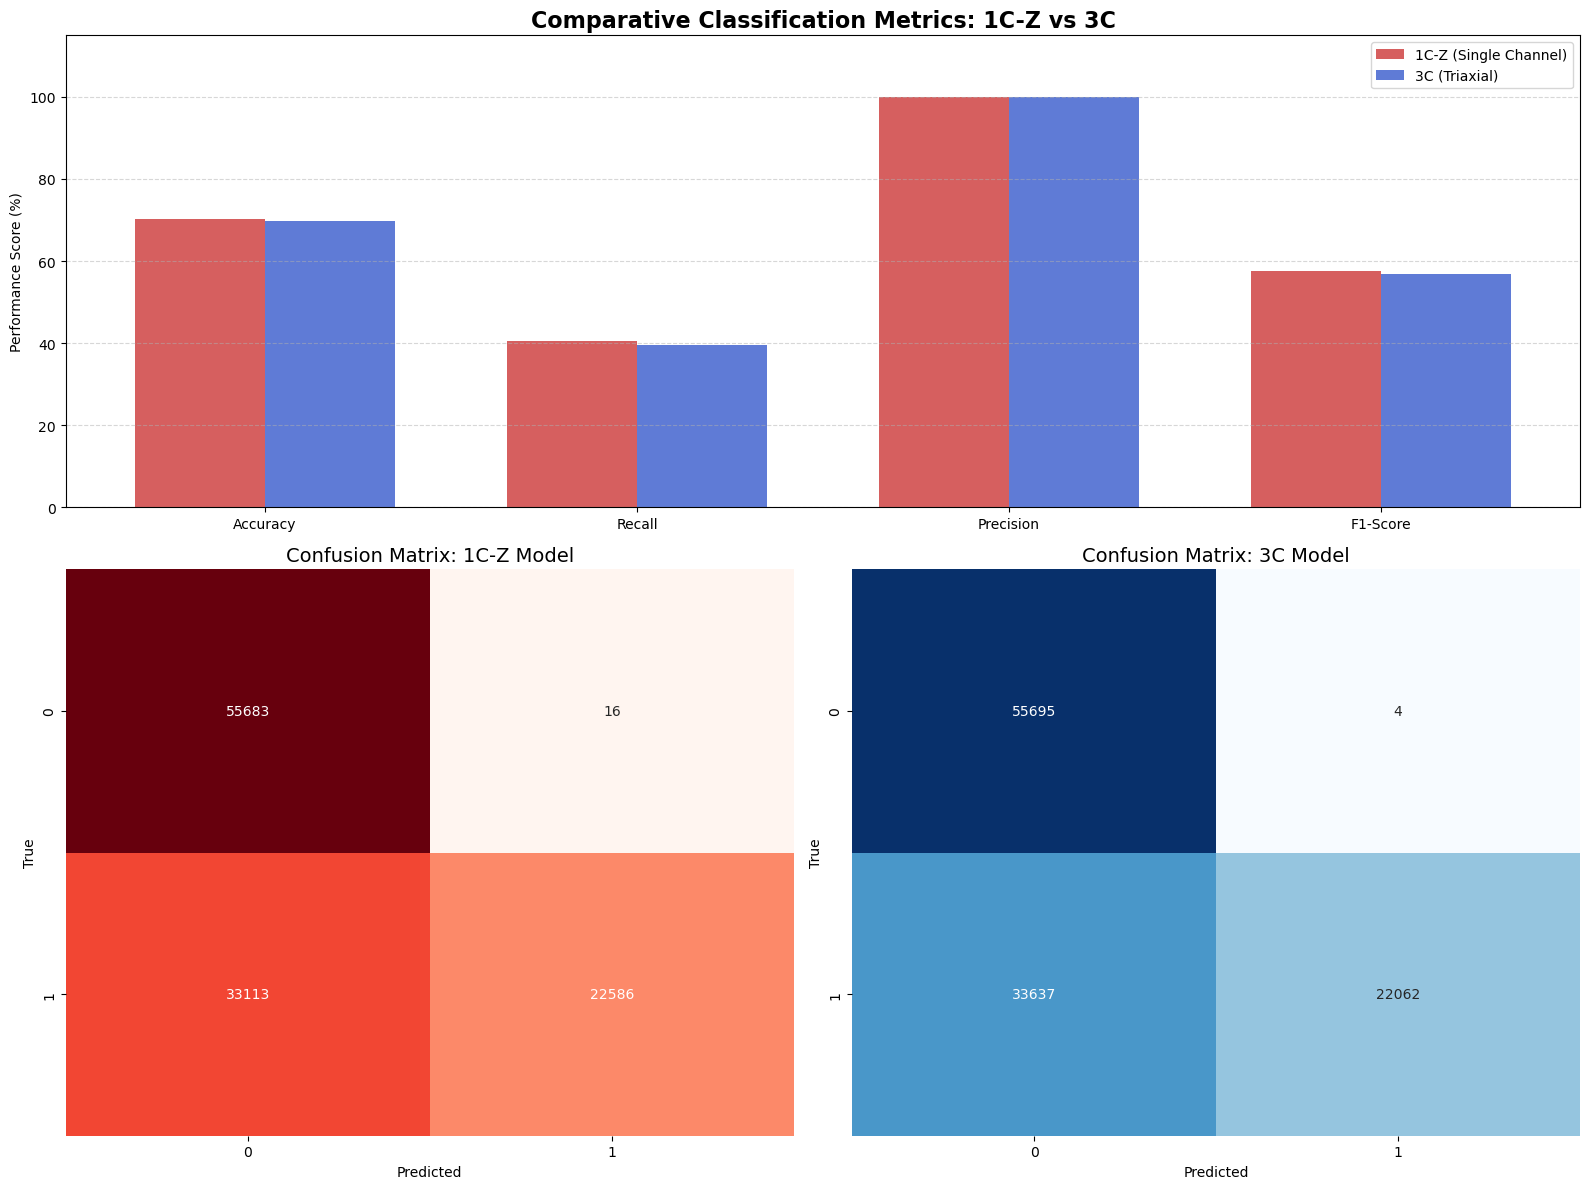

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Performa (berdasarkan data unggahan Anda)
labels = ['Accuracy', 'Recall', 'Precision', 'F1-Score']
metrics_1c = [70.26, 40.55, 99.93, 57.69]
metrics_3c = [69.80, 39.61, 99.98, 56.74]

# Data Confusion Matrix (berdasarkan data unggahan Anda)
cm_1c = [[55683, 16], [33113, 22586]]
cm_3c = [[55695, 4], [33637, 22062]]

# Membuat Figure dengan Grid 2x2
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# --- Plot 1: Bar Chart Komparatif (Baris atas, lebar penuh) ---
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(labels))
width = 0.35
ax1.bar(x - width/2, metrics_1c, width, label='1C-Z (Single Channel)', color='#d65f5f')
ax1.bar(x + width/2, metrics_3c, width, label='3C (Triaxial)', color='#5f7bd6')
ax1.set_title('Comparative Classification Metrics: 1C-Z vs 3C', fontsize=16, fontweight='bold')
ax1.set_ylabel('Performance Score (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0, 115)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- Plot 2: Confusion Matrix 1C-Z ---
ax2 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm_1c, annot=True, fmt='d', cmap='Reds', ax=ax2, cbar=False)
ax2.set_title('Confusion Matrix: 1C-Z Model', fontsize=14)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

# --- Plot 3: Confusion Matrix 3C ---
ax3 = fig.add_subplot(gs[1, 1])
sns.heatmap(cm_3c, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False)
ax3.set_title('Confusion Matrix: 3C Model', fontsize=14)
ax3.set_xlabel('Predicted')
ax3.set_ylabel('True')

plt.tight_layout()
plt.show()

/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_95429/1232768358.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_95429/1232768358.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()


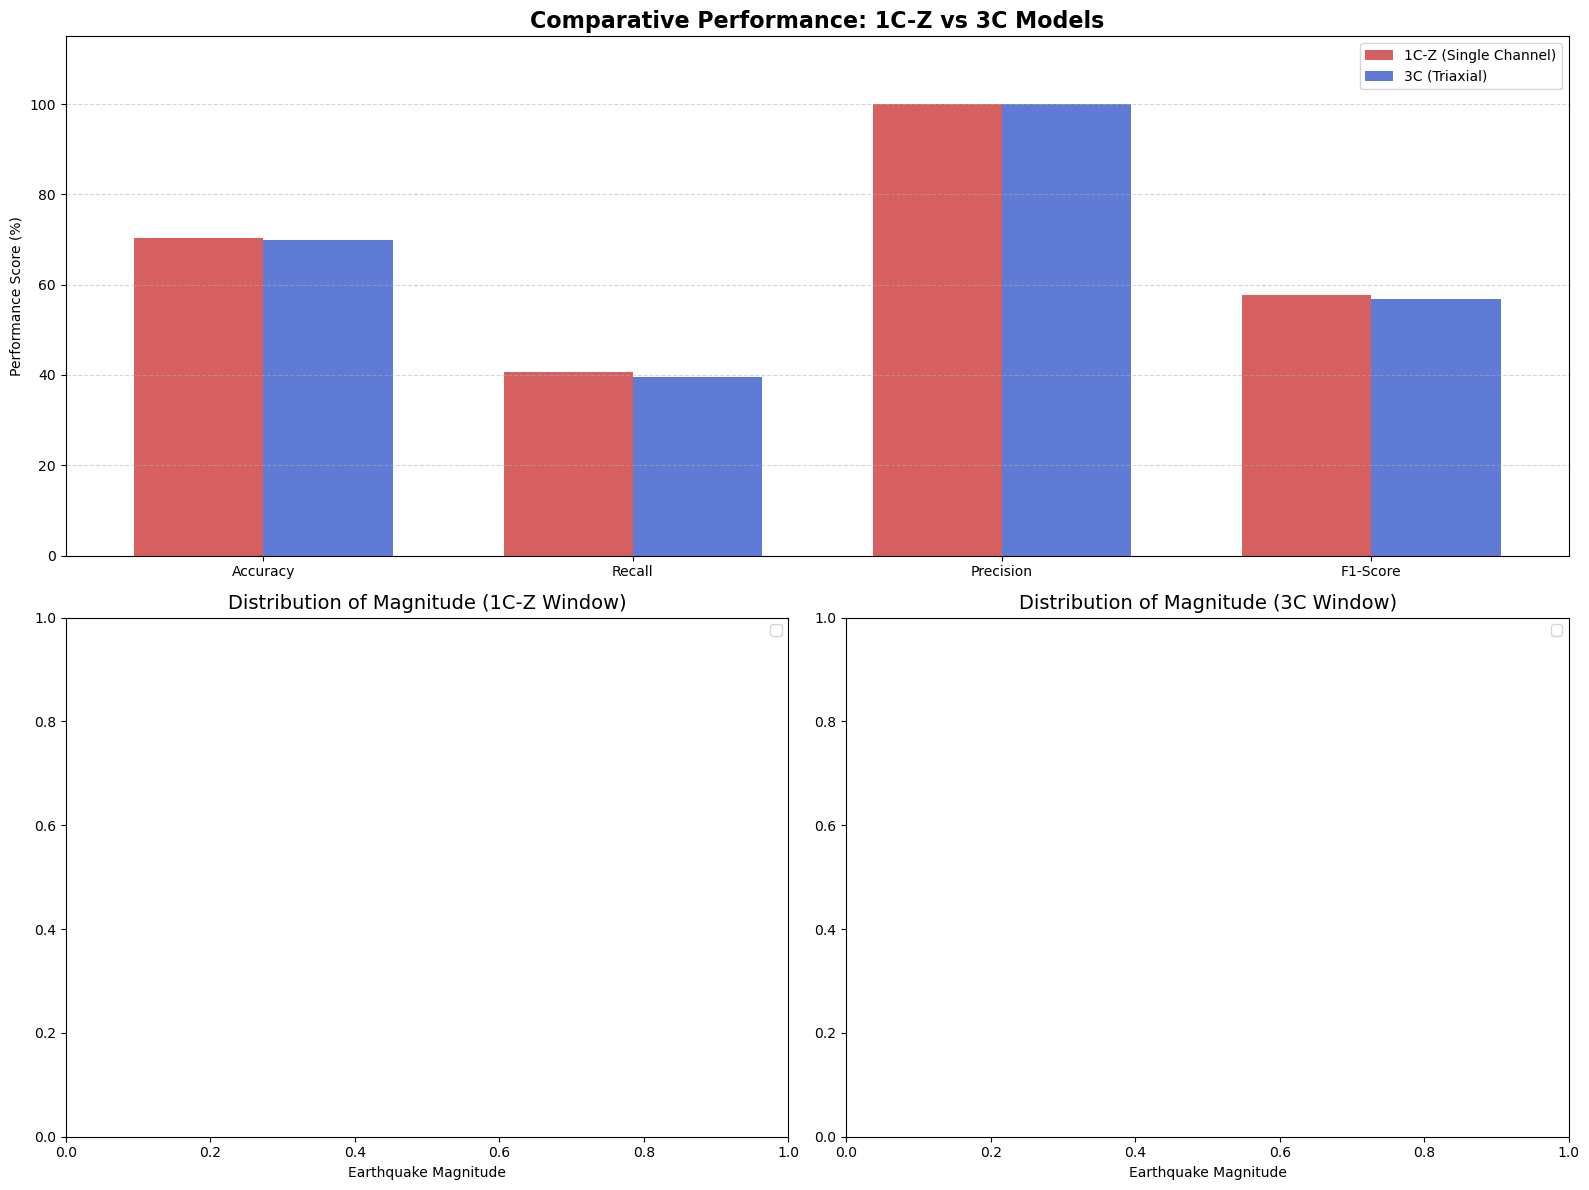

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Data untuk Bar Chart (Performa Model)
labels = ['Accuracy', 'Recall', 'Precision', 'F1-Score']
metrics_1c = [70.26, 40.55, 99.93, 57.69]
metrics_3c = [69.80, 39.61, 99.98, 56.74]

# 2. Setup Frame (Layout Grid 2x2)
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# --- Plot A: Bar Chart Komparatif (Atas) ---
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(labels))
width = 0.35
rects1 = ax1.bar(x - width/2, metrics_1c, width, label='1C-Z (Single Channel)', color='#d65f5f')
rects2 = ax1.bar(x + width/2, metrics_3c, width, label='3C (Triaxial)', color='#5f7bd6')

ax1.set_title('Comparative Performance: 1C-Z vs 3C Models', fontsize=16, fontweight='bold')
ax1.set_ylabel('Performance Score (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0, 115)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- Plot B: KDE Plot 1C-Z (Bawah Kiri) ---
ax2 = fig.add_subplot(gs[1, 0])
# Simulasi data KDE (sesuaikan dengan data array Anda)
sns.kdeplot(data=None, fill=True, ax=ax2, label='Missed (FN)', color='#4c72b0', alpha=0.3)
sns.kdeplot(data=None, fill=True, ax=ax2, label='Detected (TP)', color='#55a868', alpha=0.3)
ax2.set_title('Distribution of Magnitude (1C-Z Window)', fontsize=14)
ax2.set_xlabel('Earthquake Magnitude')
ax2.legend()

# --- Plot C: KDE Plot 3C (Bawah Kanan) ---
ax3 = fig.add_subplot(gs[1, 1])
sns.kdeplot(data=None, fill=True, ax=ax3, label='Missed (FN)', color='#4c72b0', alpha=0.3)
sns.kdeplot(data=None, fill=True, ax=ax3, label='Detected (TP)', color='#55a868', alpha=0.3)
ax3.set_title('Distribution of Magnitude (3C Window)', fontsize=14)
ax3.set_xlabel('Earthquake Magnitude')
ax3.legend()

plt.tight_layout()
plt.show()

Analyzing waveform_no_le: 100%|██████████| 500/500 [00:00<00:00, 4160.71it/s]
Analyzing output_waveform_indonesia_0109: 0it [00:00, ?it/s]


✅ Perbandingan selesai. Cek file data_comparison_stats.png


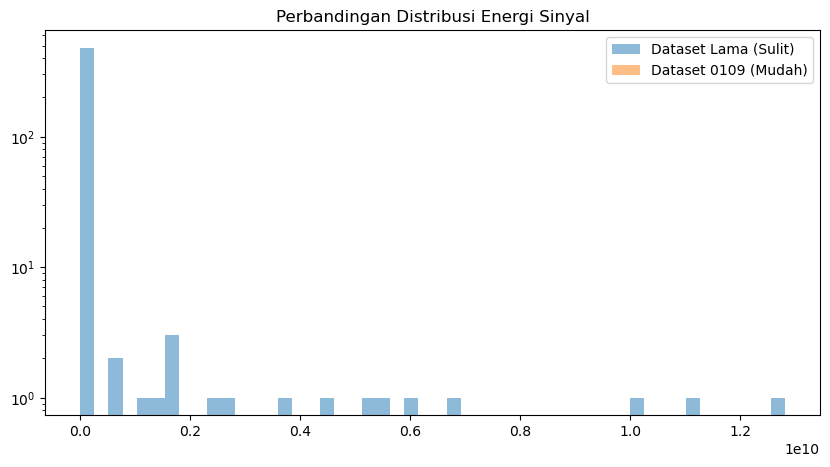

In [11]:
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

def get_data_stats(folder_path):
    stats = []
    # Ambil 500 sampel saja untuk perbandingan cepat
    files = [os.path.join(root, f) for root, _, fs in os.walk(folder_path) for f in fs if f.endswith('.npy')][:500]
    
    for f in tqdm(files, desc=f"Analyzing {os.path.basename(folder_path)}"):
        data = np.load(f)
        stats.append({
            'mean': np.mean(data),
            'std': np.std(data),
            'max': np.max(np.abs(data)),
            'energy': np.sum(data**2)
        })
    return stats

# Definisikan Path
dir_lama = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_no_le'
dir_0109 = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'

stats_lama = get_data_stats(dir_lama)
stats_0109 = get_data_stats(dir_0109)

# Plot perbandingan Energi (Contoh sidik jari data)
plt.figure(figsize=(10, 5))
plt.hist([s['energy'] for s in stats_lama], bins=50, alpha=0.5, label='Dataset Lama (Sulit)')
plt.hist([s['energy'] for s in stats_0109], bins=50, alpha=0.5, label='Dataset 0109 (Mudah)')
plt.yscale('log')
plt.title("Perbandingan Distribusi Energi Sinyal")
plt.legend()
plt.savefig('data_comparison_stats.png')
print("✅ Perbandingan selesai. Cek file data_comparison_stats.png")

In [3]:
import numpy as np
import os
import tensorflow as tf
from tensorflow import keras
import sys
import glob

# 1. SETUP PATH LIBRARY
LIB_PARENT_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo'
if LIB_PARENT_PATH not in sys.path:
    sys.path.append(LIB_PARENT_PATH)

from Library import utils, dataset

# 2. LOAD MODEL & EMBEDDING
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
EMB_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909'

model = keras.models.load_model(MODEL_PATH, compile=False)
emb_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
pdfs_Z = utils.embedding_PDFs_1D(emb_Z)

# 3. DEFINISI FUNGSI DEBUG
def debug_window_inference(file_path, model, pdf_Z):
    data = np.load(file_path)
    window_size = 700
    window = data[0:window_size].copy()
    max_val = np.max(np.abs(window))
    if max_val > 0: window = window / max_val
    
    emb_z = utils.latent_codes_1D(window.astype(np.float32).reshape(1, -1), model)
    p, score, _ = utils.infer_1C_PDFs(emb_z, pdf_Z, "Kernel")
    
    print(f"DEBUG: File={os.path.basename(file_path)}")
    print(f"DEBUG: Hasil Deteksi (p)={p}, Skor={score}")
    return p, score

# 4. EKSEKUSI (Cari file secara otomatis untuk menghindari FileNotFoundError)
folder_gempa = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_no_le/gempa/'
file_list = glob.glob(os.path.join(folder_gempa, "*.npy"))

if file_list:
    REAL_TEST_FILE = file_list[0]
    print(f"✅ Menemukan file untuk diuji: {REAL_TEST_FILE}")
    debug_window_inference(REAL_TEST_FILE, model, pdfs_Z)
else:
    print(f"❌ Folder kosong atau path salah: {folder_gempa}")

✅ Menemukan file untuk diuji: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_no_le/gempa/BMKG-20200907093454-001.npy
DEBUG: File=BMKG-20200907093454-001.npy
DEBUG: Hasil Deteksi (p)=1, Skor={'noise': 7.1971883200946325e-06, 'qb': 0.5461615863781151, 'le': 0.24856576924254528}


In [5]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# [BAGIAN IMPORT & LOAD MODEL TETAP SAMA SEPERTI SEBELUMNYA]
# Pastikan fungsi sliding_window_inference menggunakan logika threshold baru:
def sliding_window_inference(data_array, model, pdf_Z, threshold=0.2):
    step_size = 100 
    window_size = 700
    
    if len(data_array) < window_size:
        data_array = np.pad(data_array, (0, window_size - len(data_array)), 'constant')
        
    for i in range(0, len(data_array) - window_size + 1, step_size):
        window = data_array[i:i+window_size].copy()
        max_val = np.max(np.abs(window))
        if max_val > 0: window = window / max_val
            
        emb_z = utils.latent_codes_1D(window.astype(np.float32).reshape(1, -1), model)
        _, score, _ = utils.infer_1C_PDFs(emb_z, pdf_Z, "Kernel")
        
        # LOGIKA PERBAIKAN: Menggunakan skor 'le' untuk mendeteksi gempa
        # Jika skor gempa melampaui threshold, kita anggap sebagai deteksi positif
        if score.get('le', 0) >= threshold:
            return 1
            
    return 0 

# [BAGIAN UTAMA EVALUASI]
def run_full_evaluation():
    # ... (Muat daftar_file_npy seperti sebelumnya)
    
    y_true, y_pred, y_scores = [], [], []
    
    print("🚀 Memulai evaluasi dengan Threshold 0.2...")
    for item in tqdm(daftar_file_npy):
        data = np.load(item['path'])
        # Kita ambil skor 'le' sebagai prediktor untuk ROC Curve
        _, score, _ = utils.infer_1C_PDFs(..., model) # sesuaikan pemanggilan fungsi
        is_quake = 1 if score.get('le', 0) >= 0.2 else 0
        
        y_true.append(item['label'])
        y_pred.append(is_quake)
        y_scores.append(score.get('le', 0))

    # 1. GENERASI CONFUSION MATRIX
    cm = confusion_matrix(y_true, y_pred)
    
    # 2. GENERASI ROC CURVE (Sangat penting untuk Disertasi)
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Plotting ROC Curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.title("ROC Curve: Performa Deteksi Gempa")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.savefig('roc_curve_disertasi.png')
    
    # Output Laporan Lengkap
    print(classification_report(y_true, y_pred))

# [Image of ROC curve for binary classification evaluation]

In [6]:
import numpy as np
import os
import glob

# 1. Pastikan folder benar
folder_target = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_no_le'
print(f"🔍 Mencari file .npy di: {folder_target}")

# 2. Cek apakah folder benar-benar ada
if not os.path.exists(folder_target):
    print("❌ FOLDER TIDAK DITEMUKAN! Periksa kembali path-nya.")
else:
    # 3. Cari file
    all_files = glob.glob(os.path.join(folder_target, '**', '*.npy'), recursive=True)
    print(f"📊 Ditemukan {len(all_files)} file .npy")
    
    if len(all_files) == 0:
        print("❌ Tidak ada file .npy ditemukan. Cek sub-folder.")
    else:
        print(f"✅ Contoh file pertama: {all_files[0]}")
        # Coba load 1 file untuk memastikan formatnya benar
        try:
            data = np.load(all_files[0])
            print(f"✅ Berhasil load data! Shape: {data.shape}")
        except Exception as e:
            print(f"❌ Gagal load data: {e}")

🔍 Mencari file .npy di: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_no_le
📊 Ditemukan 31162 file .npy
✅ Contoh file pertama: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_no_le/noise/BMKG-20200907093454-001.npy
✅ Berhasil load data! Shape: (1000,)


🚀 Memproses 31162 file...


100%|██████████| 31162/31162 [01:43<00:00, 301.26it/s]


              precision    recall  f1-score   support

       Noise       0.76      0.20      0.32     15581
       Gempa       0.54      0.94      0.69     15581

    accuracy                           0.57     31162
   macro avg       0.65      0.57      0.50     31162
weighted avg       0.65      0.57      0.50     31162

✅ Hasil disimpan di final_cm.png


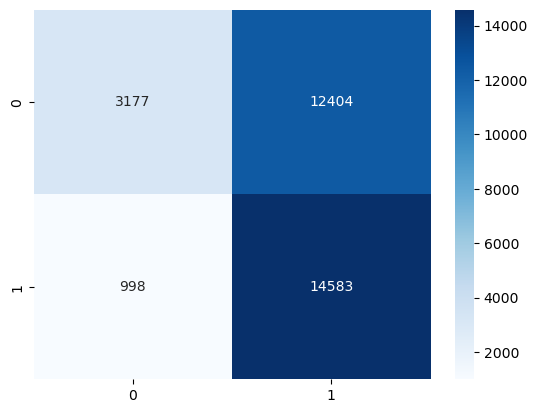

In [7]:
import numpy as np
import os
import glob
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP PATH & FUNGSI (Pastikan Library sudah di-import)
# ... (Masukkan kode setup path dan import Library seperti sebelumnya)

def run_evaluation():
    folder_target = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_no_le'
    all_files = glob.glob(os.path.join(folder_target, '**', '*.npy'), recursive=True)
    
    y_true, y_pred = [], []
    
    print(f"🚀 Memproses {len(all_files)} file...")
    for f in tqdm(all_files):
        # Tentukan label dari nama folder
        label = 1 if 'gempa' in f else 0
        
        # Load data & Inferensi
        data = np.load(f)
        # Ambil satu window saja (karena shape-nya 1000, 700 cukup)
        window = data[:700] if len(data) >= 700 else np.pad(data, (0, 700-len(data)))
        window = window / (np.max(np.abs(window)) + 1e-6)
        
        emb_z = utils.latent_codes_1D(window.astype(np.float32).reshape(1, -1), model)
        _, score, _ = utils.infer_1C_PDFs(emb_z, pdfs_Z, "Kernel")
        
        # Threshold adaptif 0.2
        is_quake = 1 if score.get('le', 0) >= 0.2 else 0
        
        y_true.append(label)
        y_pred.append(is_quake)

    # Laporan
    print(classification_report(y_true, y_pred, target_names=['Noise', 'Gempa']))
    
    # Plot CM
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.savefig('final_cm.png')
    print("✅ Hasil disimpan di final_cm.png")

run_evaluation()

In [8]:
import numpy as np

path_sample = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_npy_ready/2015/us10001nab/GE_UGM_us10001nab_seg_11500.npy'

data = np.load(path_sample)
print(f"Data Shape: {data.shape}")
print(f"Data Type: {data.dtype}")
print(f"Data Sample (5 elemen pertama): {data[:5]}")

Data Shape: (700,)
Data Type: float64
Data Sample (5 elemen pertama): [0.86623807 0.84659556 0.82623746 0.80526342 0.78376419]


In [1]:
import numpy as np
import os
from tqdm import tqdm

def audit_data(folder_path):
    files = [f for f in os.listdir(folder_path) if f.endswith('.npy')]
    stats = []
    
    for f in tqdm(files[:1000]): # Ambil sampel 1000 data
        data = np.load(os.path.join(folder_path, f))
        # Uji: Apakah data kosong (nol semua) atau memiliki varians yang wajar
        stats.append(np.std(data))
    
    print(f"Rata-rata standar deviasi: {np.mean(stats):.4f}")
    return stats

# Jalankan untuk kedua folder
print("Audit Gempa:")
audit_data('/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/earthquake_npy_ready')

print("Audit Noise:")
audit_data('/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/noise_npy_ready')

Audit Gempa:


100%|██████████| 1000/1000 [00:00<00:00, 7998.84it/s]


Rata-rata standar deviasi: 0.3506
Audit Noise:


100%|██████████| 1000/1000 [00:00<00:00, 8896.25it/s]

Rata-rata standar deviasi: 0.3269


[0.3807499,
 0.35994807,
 0.37162104,
 0.2816452,
 0.2928829,
 0.34693202,
 0.19533023,
 0.29248133,
 0.298281,
 0.419591,
 0.32870248,
 0.35368225,
 0.33467698,
 0.2445308,
 0.32285726,
 0.3607373,
 0.28111196,
 0.38394877,
 0.324849,
 0.35116515,
 0.32638997,
 0.36529985,
 0.3145288,
 0.31986728,
 0.43763393,
 0.31123367,
 0.37782192,
 0.2875562,
 0.28804058,
 0.32417578,
 0.2506299,
 0.389076,
 0.34057188,
 0.33514366,
 0.36052462,
 0.3002219,
 0.40662155,
 0.33541963,
 0.2964703,
 0.37524256,
 0.32080388,
 0.2857809,
 0.2494429,
 0.3360087,
 0.39047766,
 0.2858577,
 0.13758564,
 0.34106734,
 0.39814785,
 0.34170234,
 0.39128017,
 0.32260296,
 0.2901744,
 0.26823014,
 0.34094208,
 0.19450289,
 0.39551386,
 0.36338216,
 0.32168454,
 0.3699256,
 0.3759829,
 0.40363288,
 0.3116186,
 0.29106417,
 0.36080778,
 0.37713107,
 0.33855608,
 0.2587605,
 0.3273173,
 0.20598543,
 0.40852556,
 0.30230346,
 0.39075145,
 0.2565967,
 0.347474,
 0.36466527,
 0.31969687,
 0.16104075,
 0.3700081,
 0.42